In [ ]:
# CELL 1
!pip install ultralytics roboflow opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
# CELL 2
import os
import random
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# CELL 3
# Initialize Roboflow with your API key
rf = Roboflow(api_key="liTnEQzslDnWShepfarJ") # Keep your API key here!

# Using a currently active, public dataset from Roboflow Universe
project = rf.workspace("curacel-ai").project("car-damage-detection-5ioys")
version = project.version(1)
dataset = version.download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Damage-Detection-1 in yolov8:: 100%|██████████| 32664/32664 [00:06<00:00, 4685.56it/s]


Dataset downloaded to: /content/Car-Damage-Detection-1


In [ ]:
# CELL 4
# Load a pre-trained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

# Train the model using the data.yaml from the downloaded dataset
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,       # Number of training loops
    imgsz=640,       # Image resolution
    batch=16,        # Number of images processed at once
    name='damage_detector_v1' # Output folder name
)

print("Training finished! Weights saved to: runs/detect/damage_detector_v1/weights/best.pt")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Damage-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=damage_detector_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

In [ ]:
# CELL 5
# MOCK PRICING DATABASE (Part + Damage Type)
# Note: The keys here must match the class names in your dataset!
PRICING_DB = {
    'bumper': 400.00,
    'door': 600.00,
    'fender': 350.00,
    'headlight': 250.00,
    'dent': 150.00,       # Base cost to fix a dent
    'scratch': 75.00,     # Base cost to fix a scratch
    'glass_shatter': 300.00
}

def generate_estimate(image_path, model_path='runs/detect/damage_detector_v1/weights/best.pt'):
    # Load your freshly trained model
    trained_model = YOLO(model_path)

    # Run inference
    results = trained_model(image_path)

    total_estimate = 0.0
    detected_issues = []

    print(f"\n--- REPAIR ESTIMATE REPORT ---")

    for r in results:
        boxes = r.boxes
        for box in boxes:
            class_id = int(box.cls[0])
            class_name = trained_model.names[class_id]
            confidence = float(box.conf[0])

            # Only count detections with over 30% confidence
            if confidence > 0.30:
                cost = PRICING_DB.get(class_name, 100.00) # Default $100 if not in DB
                total_estimate += cost
                detected_issues.append(class_name)

                print(f"Detected: {class_name.upper()} (Confidence: {confidence:.2f}) -> Estimated Cost: ${cost:.2f}")

    print("------------------------------")
    print(f"TOTAL ESTIMATED REPAIR COST: ${total_estimate:.2f}\n")

    # Display the image with bounding boxes
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.show()


image 1/1 /content/Car-Damage-Detection-1/test/images/major_roof-9-_jpg.rf.628747049b27181addbdf0ba49afd6d1.jpg: 640x640 1 Front-Windscreen-Damage, 1 roof-dent, 8.9ms
Speed: 7.0ms preprocess, 8.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

--- REPAIR ESTIMATE REPORT ---
Detected: FRONT-WINDSCREEN-DAMAGE (Confidence: 0.92) -> Estimated Cost: $100.00
Detected: ROOF-DENT (Confidence: 0.91) -> Estimated Cost: $100.00
------------------------------
TOTAL ESTIMATED REPAIR COST: $200.00



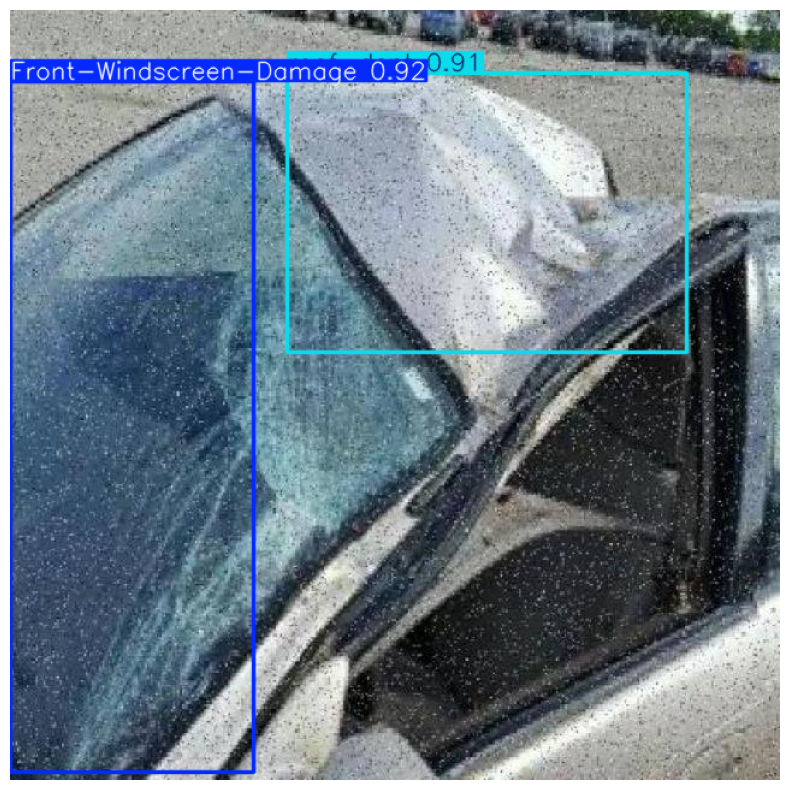

In [ ]:
# CELL 6
# Path to the test images downloaded in Cell 3
test_images_dir = os.path.join(dataset.location, 'test', 'images')

# Get a list of all images in the test directory
test_images = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

if test_images:
    # Pick a random test image
    random_image = random.choice(test_images)
    image_to_test = os.path.join(test_images_dir, random_image)

    # Run the estimate function
    generate_estimate(image_to_test)
else:
    print("No test images found in the dataset.")

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your previously saved custom model
saved_model = YOLO('runs/detect/damage_detector_v1/weights/best.pt')

# 2. Run it on a new image




FileNotFoundError: path/to/new_car_photo.jpg does not exist